In [1]:
import pandas as pd

# Using a public, verified mirror of the Kaggle Telco dataset
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)

# Let's test it again
print("Dataset Dimensions:", df.shape)

Dataset Dimensions: (7043, 21)


In [2]:
# 2. Look at the first 5 rows
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovie

In [5]:
print("\n--- Target Class Distribution ---")
print(df['Churn'].value_counts(normalize=True))


--- Target Class Distribution ---
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
# 1. Force TotalCharges to be numeric, turning spaces into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many missing values we just created
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# 3. Handle the missing values
# Since these are brand new customers (tenure = 0), their TotalCharges should logically be 0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 4. Drop customerID since it's a unique identifier and useless for training models
df = df.drop(columns=['customerID'])

print("Data types fixed successfully!")

Missing values in TotalCharges: 11
Data types fixed successfully!


In [4]:
# 1. Convert Churn from Yes/No to 1/0 for easy math
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Check churn rate by Contract type
print("--- Churn Rate by Contract Type ---")
print(df.groupby('Contract')['Churn_Numeric'].mean() * 100)

# 3. Check churn rate by Internet Service type
print("\n--- Churn Rate by Internet Service ---")
print(df.groupby('InternetService')['Churn_Numeric'].mean() * 100)

--- Churn Rate by Contract Type ---
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Numeric, dtype: float64

--- Churn Rate by Internet Service ---
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_Numeric, dtype: float64


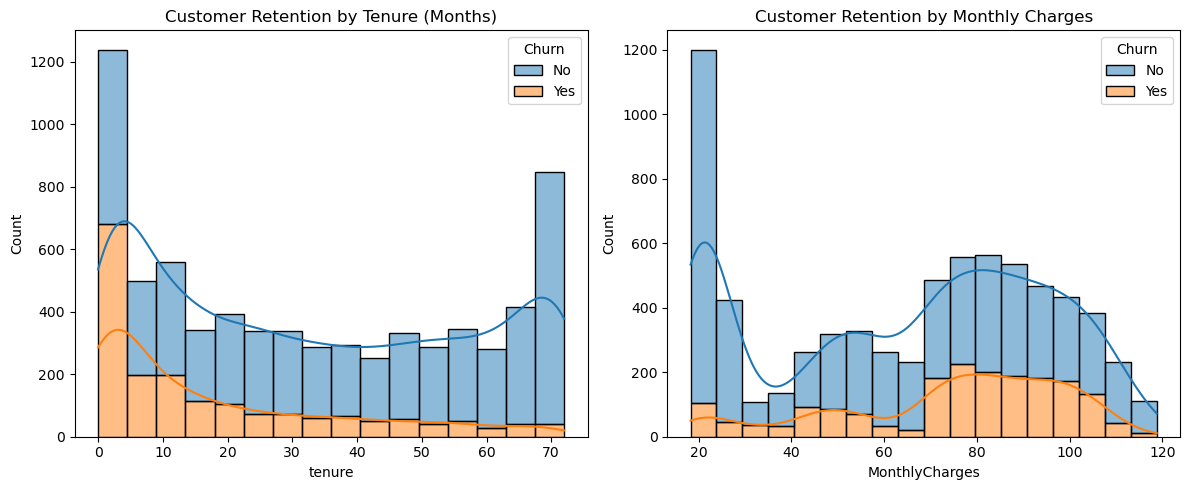

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Tenure vs Churn
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True)
plt.title('Customer Retention by Tenure (Months)')

# Plot 2: Monthly Charges vs Churn
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', kde=True)
plt.title('Customer Retention by Monthly Charges')

plt.tight_layout()
plt.show()

In [7]:
# Create a feature tracking if the customer has a family setup
df['Is_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)

# Drop the helper target column from EDA if it's still there
if 'Churn_Numeric' in df.columns:
    df = df.drop(columns=['Churn_Numeric'])

In [8]:
# 1. Separate the target variable (Y) and features (X)
X = df.drop(columns=['Churn'])
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Identify binary and multi-class columns
binary_cols = []
multi_cols = []

for col in X.select_dtypes(include=['object']).columns:
    if X[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

# 3. Label Encode the binary text columns manually
for col in binary_cols:
    # E.g., Male -> 1, Female -> 0 or Yes -> 1, No -> 0
    X[col] = pd.factorize(X[col])[0]

# 4. One-Hot Encode the multi-class columns using pandas
X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

# Ensure all boolean outputs from get_dummies are converted to 1 and 0 ints
X = X.astype(float)

print("Processed Features Shape:", X.shape)
print("\n--- Model-Ready Columns Preview ---")
print(X.dtypes.head(10))

Processed Features Shape: (7043, 31)

--- Model-Ready Columns Preview ---
gender              float64
SeniorCitizen       float64
Partner             float64
Dependents          float64
tenure              float64
PhoneService        float64
PaperlessBilling    float64
MonthlyCharges      float64
TotalCharges        float64
Is_Family           float64
dtype: object


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing shapes:  X_test: {X_test.shape}, y_test: {y_test.shape}")

Training shapes: X_train: (5634, 31), y_train: (5634,)
Testing shapes:  X_test: (1409, 31), y_test: (1409,)


In [10]:
# Calculate the ratio of negative (Stayed) to positive (Churned) cases
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()

scale_weight = negative_cases / positive_cases
print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

Calculated scale_pos_weight: 2.77


In [14]:
!pip install xgboost
from xgboost import XGBClassifier

# Initialize the model with baseline hyperparameters and our weight adjustment
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Model trained successfully!")

XGBoost Model trained successfully!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on test data
y_pred = xgb_model.predict(X_test)

# Print the metrics report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(f"True Negatives (Predicted Stay, Actually Stayed): {cm[0][0]}")
print(f"False Positives (Predicted Churn, Actually Stayed): {cm[0][1]}")
print(f"False Negatives (Predicted Stay, Actually Churned): {cm[1][0]}")
print(f"True Positives (Predicted Churn, Actually Churned): {cm[1][1]}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

--- Confusion Matrix ---
True Negatives (Predicted Stay, Actually Stayed): 757
False Positives (Predicted Churn, Actually Stayed): 278
False Negatives (Predicted Stay, Actually Churned): 76
True Positives (Predicted Churn, Actually Churned): 298


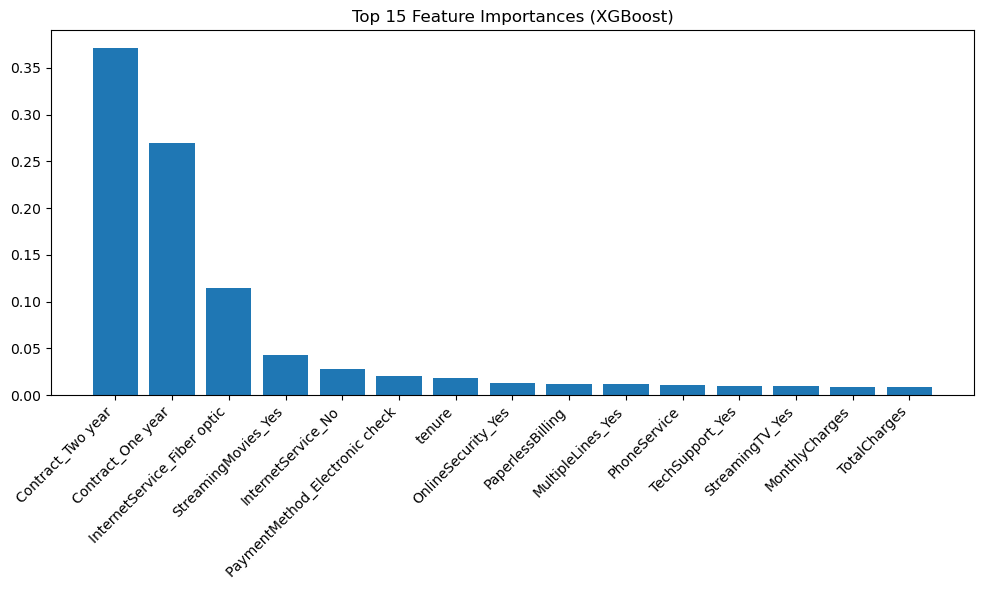

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get feature importances from the trained model
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# 2. Sort them in descending order
indices = np.argsort(importances)[::-1]

# 3. Plot the top 15 most important features
plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances (XGBoost)")
plt.bar(range(15), importances[indices[:15]], align="center")
plt.xticks(range(15), feature_names[indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import pickle

# Save the model artifact
with open('src/xgb_churn_model.pkl', 'wb') as model_file:
    pickle.dump(xgb_model, model_file)

# Save the training columns list to ensure alignment later
with open('src/model_columns.pkl', 'wb') as columns_file:
    pickle.dump(list(X_train.columns), columns_file)

print("Artifacts successfully saved inside the 'src/' folder!")

FileNotFoundError: [Errno 2] No such file or directory: 'src/xgb_churn_model.pkl'